<a href="https://colab.research.google.com/github/DANIEL-VELASCO/taller1-deep-learning/blob/main/code/punto2_cnn_fashion_mnist/02_figuras_informe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Punto 2 · Notebook 02 – Figuras y tablas del informe

**Taller 1 – Aprendizaje Profundo** · Maestría en Inteligencia Artificial, Pontificia Universidad Javeriana

El notebook `01` entrena y deja todo en `results/punto2/`. Este lee esos archivos y arma las figuras
y las tablas que van al informe. No entrena nada, así que corre en CPU en unos segundos y se puede
repetir las veces que haga falta para ajustar una gráfica sin tocar los modelos.

Necesita de `results/punto2/`: `experimentos.csv`, `historias_final.json`, `metricas_test.csv`,
`tiempos.csv`, `bootstrap.csv` y `predicciones_test.npz`. Si falta alguno, la celda de carga avisa
cuál y salta las figuras que dependan de él.

Las tablas salen en tres formatos: `.csv` para revisarlas, `.tex` para pegar en LaTeX y `.md` por si
el informe termina en Word.

## 0. Preparación

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    if not Path("/content/taller1-deep-learning").exists():
        !git clone -q https://github.com/DANIEL-VELASCO/taller1-deep-learning.git /content/taller1-deep-learning
    RAIZ = Path("/content/taller1-deep-learning")
else:
    RAIZ = Path.cwd().resolve().parents[1]

RUTA_RES = RAIZ / "results" / "punto2"
print("leyendo de", RUTA_RES)

FAMILIAS = ["cnn", "vgg16", "mobilenetv2"]
NOMBRE = {"cnn": "CNN desde cero", "vgg16": "VGG16", "mobilenetv2": "MobileNetV2"}
CLASES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Un color y un marcador fijos por familia: el mismo modelo se ve igual en todas las figuras.
# Los tres tonos se eligieron para que sigan distinguiéndose en daltonismo y en impresión gris.
COLOR = {"cnn": "#2a78d6", "vgg16": "#eb6834", "mobilenetv2": "#1baf7a"}
MARCA = {"cnn": "o", "vgg16": "s", "mobilenetv2": "^"}
TINTA, TINTA_SUAVE, MALLA = "#111111", "#52514e", "#e6e5e1"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.fontsize": 8.5, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.edgecolor": MALLA, "axes.linewidth": 0.8,
    "axes.labelcolor": TINTA_SUAVE, "text.color": TINTA,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "axes.grid": True, "grid.color": MALLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

# Rampa de un solo tono para las matrices de confusión: claro = poco, oscuro = mucho.
AZULES = LinearSegmentedColormap.from_list(
    "azules", ["#ffffff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"])


def leyenda_figura(fig, familias=None, y=-0.02):
    """Una sola leyenda por figura, debajo de los paneles, para no taparle datos a nadie."""
    familias = familias or FAMILIAS
    marcas = [Line2D([], [], color=COLOR[f], marker=MARCA[f], linestyle="none", markersize=7,
                     markeredgecolor="white", markeredgewidth=1.2, label=NOMBRE[f])
              for f in familias]
    fig.legend(handles=marcas, loc="lower center", bbox_to_anchor=(0.5, y), ncol=len(familias),
               handletextpad=0.4, columnspacing=2.2)


leyendo de /content/taller1-deep-learning/results/punto2


In [2]:
def cargar(nombre, como="csv"):
    """Devuelve el archivo si está, o None avisando, para poder correr con resultados parciales."""
    ruta = RUTA_RES / nombre
    if not ruta.exists():
        print(f"  falta {nombre}: se saltan las figuras que lo usan")
        return None
    if como == "csv":
        return pd.read_csv(ruta)
    if como == "json":
        with open(ruta, encoding="utf-8") as f:
            return json.load(f)
    return np.load(ruta)


exp = cargar("experimentos.csv")
met = cargar("metricas_test.csv")
tiempos = cargar("tiempos.csv")
boot = cargar("bootstrap.csv")
hist = cargar("historias_final.json", "json")
pred = cargar("predicciones_test.npz", "npz")

if pred is not None:
    y_test = pred["y_test"]
    probs = {f: pred[f"probs_{f}"] for f in FAMILIAS if f"probs_{f}" in pred}
    preds = {f: p.argmax(1) for f, p in probs.items()}
    print("predicciones cargadas:", list(preds))


predicciones cargadas: ['cnn', 'vgg16', 'mobilenetv2']


## 1. Los datos

Una imagen por clase, para que el informe muestre contra qué se está compitiendo. Las prendas de
torso (camiseta, pullover, abrigo, camisa) se parecen entre sí en 28×28 y son las que van a explicar
casi todos los errores más adelante.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


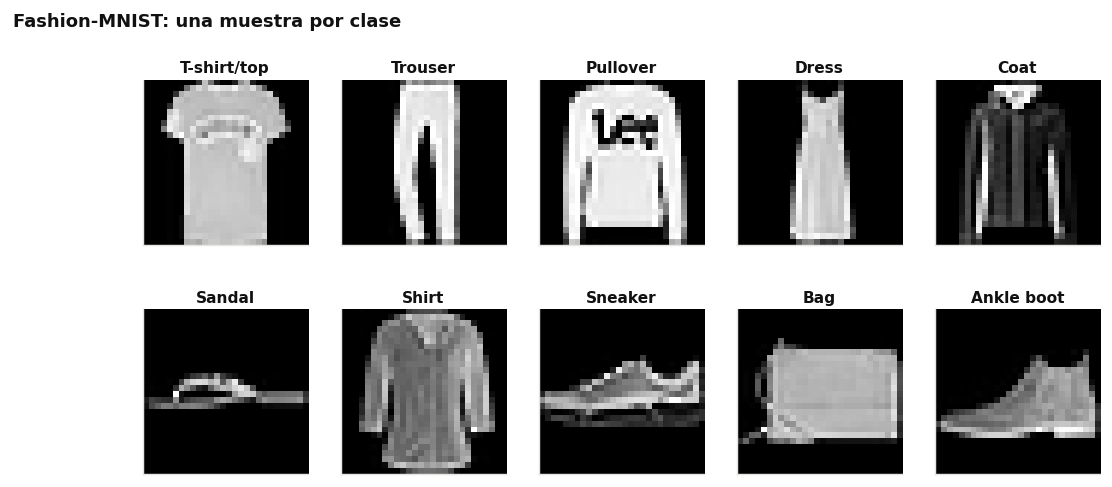

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(_, _), (x_test, y_real) = fashion_mnist.load_data()

fig, ax = plt.subplots(2, 5, figsize=(9.5, 4.2))
for c, a in enumerate(ax.flat):
    a.imshow(x_test[np.where(y_real == c)[0][0]], cmap="gray", interpolation="nearest")
    a.set_title(CLASES[c], fontsize=8.5, loc="center", pad=4)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
    for lado in a.spines.values():
        lado.set_color(MALLA)
# El título se alinea con la primera imagen; si va pegado al borde, el recorte deja un hueco a la izquierda.
fig.suptitle("Fashion-MNIST: una muestra por clase", x=ax[0, 0].get_position().x0, ha="left",
             fontsize=10, fontweight="semibold")
fig.savefig(RUTA_RES / "fig_clases.png")
plt.show()


## 2. La búsqueda de hiperparámetros

Dos lecturas de la misma tabla. A la izquierda, qué tan lejos llegó cada configuración; a la
derecha, cuánto de esa ventaja viene de memorizar el entrenamiento. Una configuración buena está
arriba y a la izquierda: buen accuracy de validación con poca brecha.

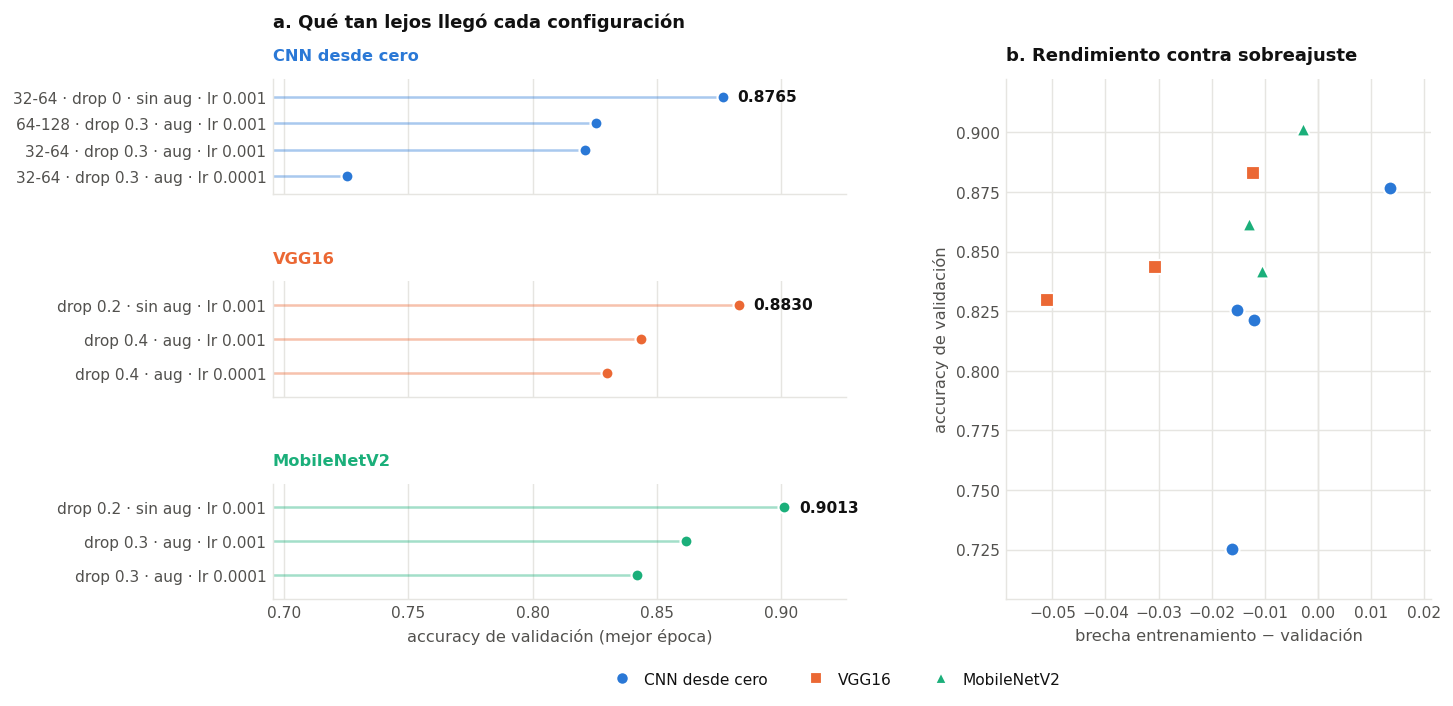

In [4]:
def etiqueta_config(cfg):
    partes = []
    if "filters" in cfg:
        partes.append("-".join(str(x) for x in cfg["filters"]))
    partes.append(f"drop {cfg['drop']:g}")
    partes.append("aug" if cfg["aug"] else "sin aug")
    partes.append(f"lr {cfg['lr']:g}")
    return " · ".join(partes)


if exp is not None:
    e = exp.copy()
    e["etiqueta"] = e.config.map(lambda s: etiqueta_config(json.loads(s)))
    presentes = [f for f in FAMILIAS if f in set(e.family)]
    lim = (e.val_accuracy.min() - 0.03, e.val_accuracy.max() + 0.025)

    # Un panel por familia a la izquierda: así cada bloque lleva su nombre en el título y
    # las etiquetas de configuración no compiten con nada.
    fig = plt.figure(figsize=(11.5, 5.2))
    rejilla = fig.add_gridspec(len(presentes), 2, width_ratios=[1.35, 1], hspace=0.75, wspace=0.32)
    a2 = fig.add_subplot(rejilla[:, 1])

    for k, f in enumerate(presentes):
        a = fig.add_subplot(rejilla[k, 0])
        bloque = e[e.family == f].sort_values("val_accuracy")
        y = np.arange(len(bloque))
        a.hlines(y, lim[0], bloque.val_accuracy, color=COLOR[f], linewidth=1.4, alpha=0.4)
        a.scatter(bloque.val_accuracy, y, color=COLOR[f], s=44, zorder=3, edgecolor="white",
                  linewidth=1.2)
        a.set_yticks(y, bloque.etiqueta)
        a.set_ylim(-0.7, len(bloque) - 0.3)
        a.set_xlim(*lim)
        a.set_title(NOMBRE[f], color=COLOR[f], fontsize=9)
        a.grid(axis="y", visible=False)
        if k < len(presentes) - 1:
            a.set_xticklabels([])
        else:
            a.set_xlabel("accuracy de validación (mejor época)")
        # Solo se rotula la ganadora: un número en cada punto sería ruido.
        g = bloque.loc[bloque.val_loss.idxmin()]
        a.annotate(f"{g.val_accuracy:.4f}", (g.val_accuracy, list(bloque.index).index(g.name)),
                   xytext=(8, 0), textcoords="offset points", va="center", fontsize=8.5,
                   fontweight="semibold", color=TINTA)
        if k == 0:
            a.text(0, 1.45, "a. Qué tan lejos llegó cada configuración", transform=a.transAxes,
                   fontsize=10, fontweight="semibold", color=TINTA)

    for f in presentes:
        bloque = e[e.family == f]
        a2.scatter(bloque.gap, bloque.val_accuracy, s=60, marker=MARCA[f], color=COLOR[f],
                   edgecolor="white", linewidth=1.2, zorder=3)
    a2.axvline(0, color=MALLA, linewidth=0.8, zorder=1)
    a2.set_xlabel("brecha entrenamiento − validación")
    a2.set_ylabel("accuracy de validación")
    a2.set_title("b. Rendimiento contra sobreajuste")
    a2.margins(x=0.12, y=0.12)

    leyenda_figura(fig, presentes, y=-0.04)
    fig.savefig(RUTA_RES / "fig_busqueda.png")
    plt.show()


## 3. Cómo entrenaron los modelos finales

Línea gruesa: validación. Línea tenue: entrenamiento. Lo que interesa mirar es la distancia entre
las dos (sobreajuste) y en qué época se aplana cada una.

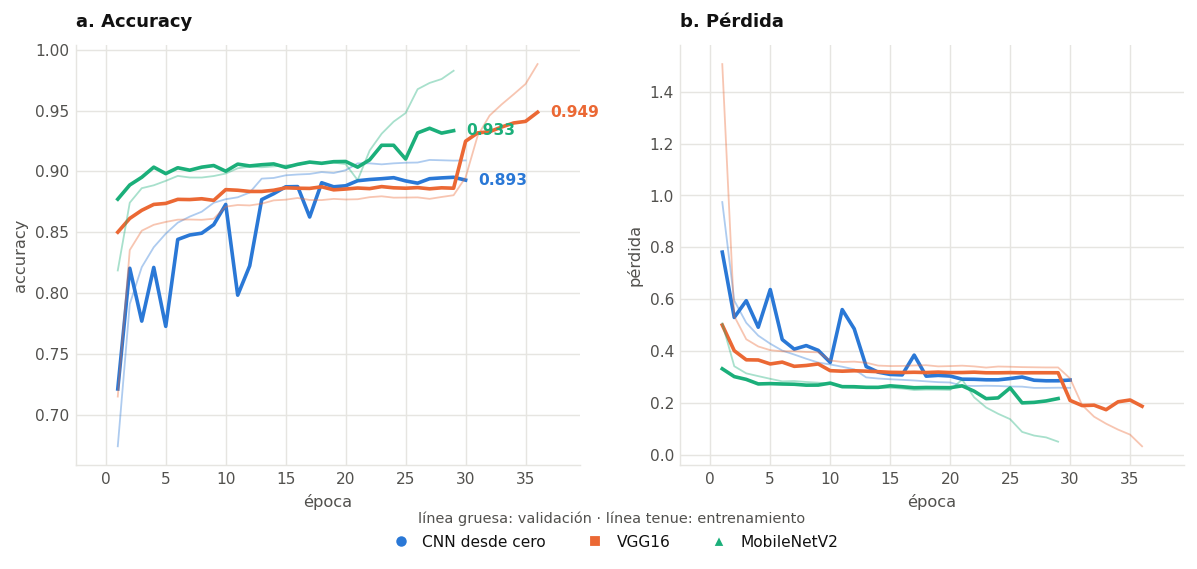

In [5]:
if hist is not None:
    presentes = [f for f in FAMILIAS if f in hist]
    fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))
    for a, metrica, titulo in [(ejes[0], "accuracy", "a. Accuracy"), (ejes[1], "loss", "b. Pérdida")]:
        for f in presentes:
            epocas = np.arange(1, len(hist[f][metrica]) + 1)
            a.plot(epocas, hist[f][metrica], color=COLOR[f], linewidth=1.0, alpha=0.38)
            a.plot(epocas, hist[f]["val_" + metrica], color=COLOR[f], linewidth=2.0)
        a.set_xlabel("época"); a.set_title(titulo)
        a.margins(x=0.10)

    # El valor final solo se rotula en el panel de accuracy: en el de pérdida las tres
    # curvas terminan muy juntas y las etiquetas se pisarían. Van todos en una columna a la
    # derecha de la curva más larga, para que ninguna línea les pase por encima.
    ultima = max(len(hist[f]["val_accuracy"]) for f in presentes)
    for f in presentes:
        serie = hist[f]["val_accuracy"]
        ejes[0].annotate(f"{serie[-1]:.3f}", (ultima, serie[-1]), xytext=(10, 0),
                         textcoords="offset points", va="center", fontsize=8.5,
                         color=COLOR[f], fontweight="semibold")
    ejes[0].set_xlim(right=ultima * 1.16)

    ejes[0].set_ylabel("accuracy"); ejes[1].set_ylabel("pérdida")
    fig.text(0.5, 0.005, "línea gruesa: validación · línea tenue: entrenamiento · a la derecha, accuracy de validación en la última época",
             ha="center", fontsize=8, color=TINTA_SUAVE)
    leyenda_figura(fig, presentes, y=-0.07)
    fig.savefig(RUTA_RES / "fig_curvas.png")
    plt.show()


## 4. Dónde se equivoca cada modelo

Matrices normalizadas por fila: cada casilla es el porcentaje de una clase real que fue a parar a
cada predicción. Normalizar permite comparar las tres en la misma escala. Se anotan solo las
casillas con al menos 1 %, para que la diagonal no quede enterrada en ceros.

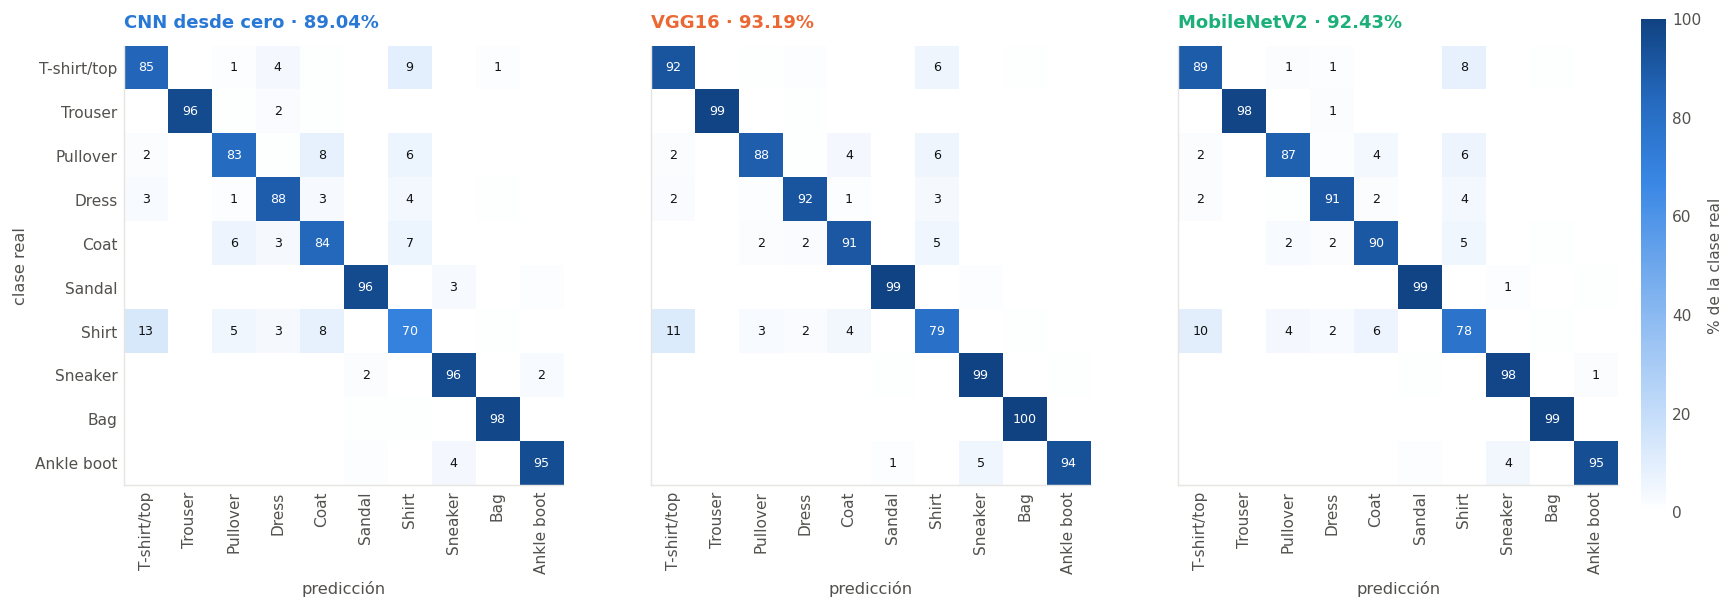

In [6]:
if pred is not None:
    from sklearn.metrics import confusion_matrix

    presentes = [x for x in FAMILIAS if x in preds]
    fig, ejes = plt.subplots(1, len(presentes), figsize=(5.1 * len(presentes), 5.2))
    ejes = np.atleast_1d(ejes)
    for k, (a, f) in enumerate(zip(ejes, presentes)):
        cm = confusion_matrix(y_test, preds[f], normalize="true") * 100
        imagen = a.imshow(cm, cmap=AZULES, vmin=0, vmax=100, interpolation="nearest")
        for i in range(10):
            for j in range(10):
                if cm[i, j] >= 1:
                    a.text(j, i, f"{cm[i, j]:.0f}", ha="center", va="center", fontsize=7,
                           color="white" if cm[i, j] > 55 else TINTA)
        a.set_xticks(range(10), CLASES, rotation=90)
        a.set_yticks(range(10), CLASES if k == 0 else [""] * 10)
        a.set_title(f"{NOMBRE[f]} · {(preds[f] == y_test).mean():.2%}", color=COLOR[f])
        a.set_xlabel("predicción")
        a.grid(False)
    ejes[0].set_ylabel("clase real")
    barra = fig.colorbar(imagen, ax=ejes, fraction=0.016, pad=0.015)
    barra.set_label("% de la clase real", fontsize=8.5)
    barra.outline.set_visible(False)
    fig.savefig(RUTA_RES / "fig_confusion.png")
    plt.show()


## 5. F1 por clase

El promedio esconde lo interesante. Las clases están ordenadas de la más difícil a la más fácil, y
el patrón es el mismo en las tres aproximaciones: *Shirt* es el cuello de botella, porque se
confunde con las otras tres prendas de torso.

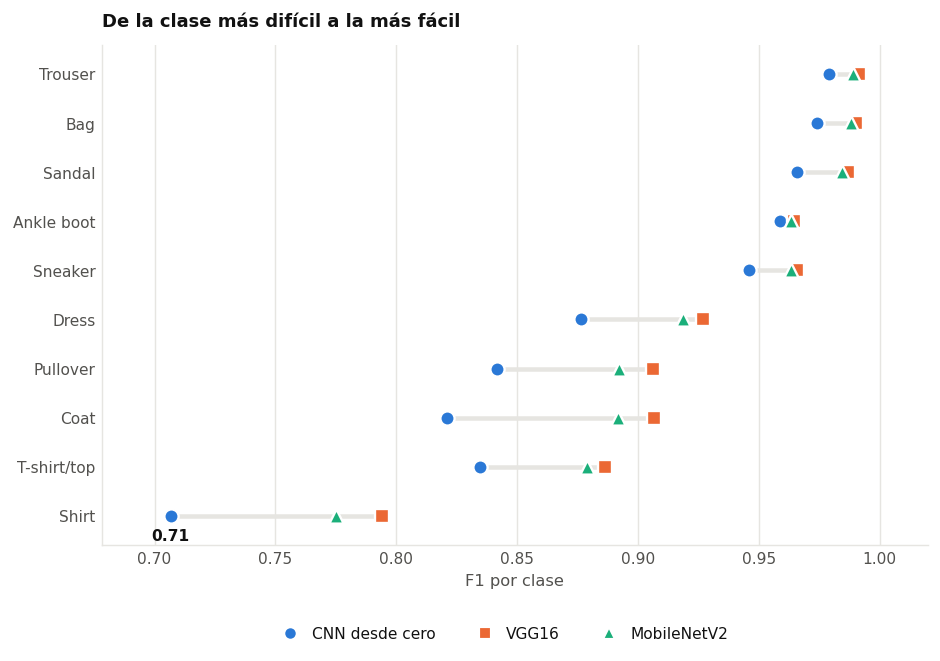

,cnn,vgg16,mobilenetv2
Shirt,0.7067,0.7940,0.7751
T-shirt/top,0.8347,0.8864,0.8788
Coat,0.8210,0.9066,0.8915
Pullover,0.8415,0.9063,0.8921
Dress,0.8762,0.9270,0.9185
Sneaker,0.9458,0.9659,0.9631
Ankle boot,0.9587,0.9645,0.9633
Sandal,0.9659,0.9870,0.9845
Bag,0.9740,0.9900,0.9881
Trouser,0.9792,0.9915,0.9889


In [7]:
if pred is not None:
    from sklearn.metrics import f1_score

    presentes = [x for x in FAMILIAS if x in preds]
    f1 = pd.DataFrame({f: f1_score(y_test, preds[f], average=None) for f in presentes}, index=CLASES)
    f1 = f1.loc[f1.mean(axis=1).sort_values().index]

    # Puntos en vez de barras: con tres series y diez clases las barras se vuelven un muro,
    # y además los puntos permiten recortar el eje sin engañar al lector.
    fig, a = plt.subplots(figsize=(8.2, 5.0))
    y = np.arange(len(f1))
    a.hlines(y, f1.min(axis=1), f1.max(axis=1), color=MALLA, linewidth=2.5, zorder=1)
    # Cada familia va un poco corrida en vertical: en las clases fáciles los tres modelos
    # empatan casi al milésimo y, sin el corrimiento, un marcador tapa al otro.
    corrimiento = dict(zip(presentes, np.linspace(0.22, -0.22, len(presentes))))
    for f in presentes:
        a.scatter(f1[f], y + corrimiento[f], marker=MARCA[f], s=62, color=COLOR[f],
                  edgecolor="white", linewidth=1.3, zorder=3)
    a.set_yticks(y, f1.index)
    a.set_ylim(-0.6, len(f1) - 0.4)
    a.set_xlabel("F1 por clase")
    a.set_title("De la clase más difícil a la más fácil")
    a.grid(axis="y", visible=False)
    a.margins(x=0.10)

    # Se rotula solo la peor casilla, que es la que se comenta en el informe.
    peor = f1.iloc[0].idxmin()
    a.annotate(f"{f1.iloc[0][peor]:.2f}", (f1.iloc[0][peor], corrimiento[peor]), xytext=(0, 9),
               textcoords="offset points", ha="center", va="bottom", fontsize=8.5,
               fontweight="semibold", color=TINTA)

    leyenda_figura(fig, presentes, y=-0.06)
    fig.savefig(RUTA_RES / "fig_f1_clase.png")
    plt.show()
    display(f1.round(4))


## 6. Lo que cuesta cada punto de accuracy

La figura de la comparación. A la izquierda, qué se gana por parámetro entrenable; a la derecha,
qué se gana por segundo de GPU. Las barras verticales son el intervalo de confianza del 95 % del
accuracy, así que dos modelos cuyas barras se solapan no están separados de forma concluyente.

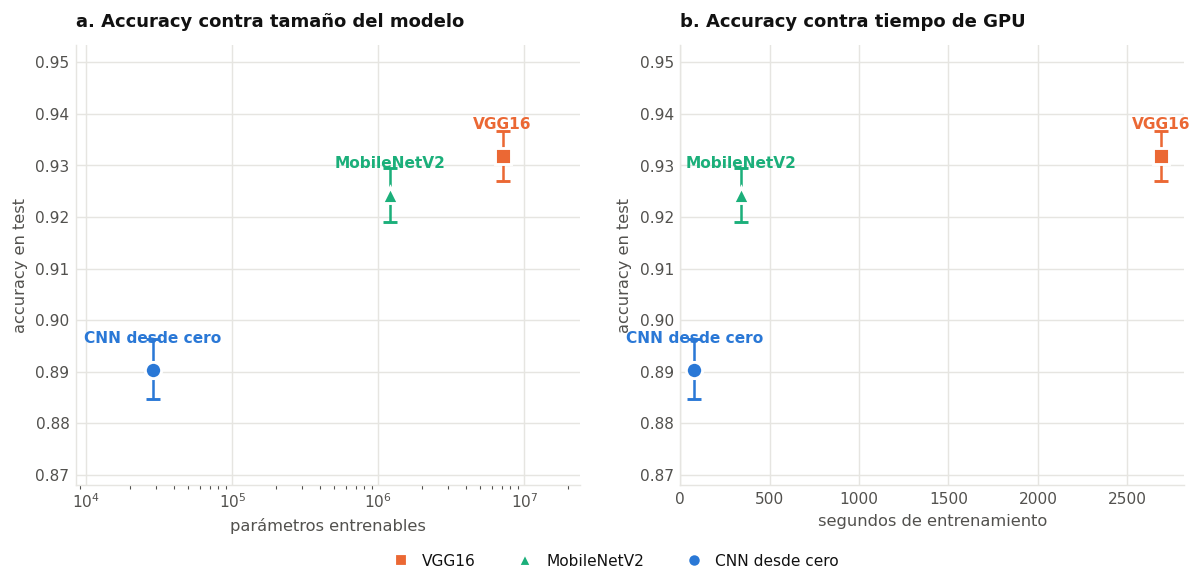

,Modelo,Accuracy,LogLoss,Precision_macro,Recall_macro,F1_macro,Parametros,Entrenables,seconds,IC95_inf,IC95_sup
0,vgg16,0.9319,0.1925,0.9327,0.9319,0.9319,14719818,7084554,2687.0060,0.9269,0.9367
1,mobilenetv2,0.9243,0.2301,0.9248,0.9243,0.9244,2270794,1207690,339.9459,0.9190,0.9295
2,cnn,0.8904,0.3095,0.8906,0.8904,0.8904,28714,28522,78.7066,0.8846,0.8963


In [8]:
if met is not None and tiempos is not None and boot is not None:
    tabla = (met.merge(tiempos.groupby("family", as_index=False).seconds.sum(),
                       left_on="Modelo", right_on="family")
                .drop(columns="family")
                .merge(boot[["Modelo", "IC95_inf", "IC95_sup"]], on="Modelo"))

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
    for a, x, etiqueta_x, titulo, log in [
        (a1, "Entrenables", "parámetros entrenables", "a. Accuracy contra tamaño del modelo", True),
        (a2, "seconds", "segundos de entrenamiento", "b. Accuracy contra tiempo de GPU", False),
    ]:
        for _, fila in tabla.iterrows():
            f = fila.Modelo
            a.errorbar(fila[x], fila.Accuracy,
                       yerr=[[fila.Accuracy - fila.IC95_inf], [fila.IC95_sup - fila.Accuracy]],
                       fmt=MARCA[f], color=COLOR[f], markersize=9, markeredgecolor="white",
                       markeredgewidth=1.6, capsize=4, elinewidth=1.4, zorder=3)
            # El nombre va al lado del punto, no encima, donde lo cruzaría la barra de error.
            # Al punto más a la derecha se le pone a la izquierda para que no se salga del panel.
            a_la_izquierda = fila[x] == tabla[x].max()
            a.annotate(NOMBRE[f], (fila[x], fila.Accuracy), xytext=(-11 if a_la_izquierda else 11, 0),
                       textcoords="offset points", ha="right" if a_la_izquierda else "left",
                       va="center", fontsize=8.5, color=COLOR[f], fontweight="semibold")
        if log:
            a.set_xscale("log")
        else:
            a.set_xlim(left=0)
        a.set_xlabel(etiqueta_x); a.set_ylabel("accuracy en test"); a.set_title(titulo)
        a.margins(x=0.22, y=0.32)

    leyenda_figura(fig, list(tabla.Modelo), y=-0.06)
    fig.savefig(RUTA_RES / "fig_comparacion.png")
    plt.show()
    display(tabla.round(4))


## 7. Los errores más confiados

Los quince casos donde el mejor modelo se equivocó con más seguridad. Sirven para argumentar en el
informe que buena parte del error residual es ambigüedad real de las imágenes y no falta de
capacidad.

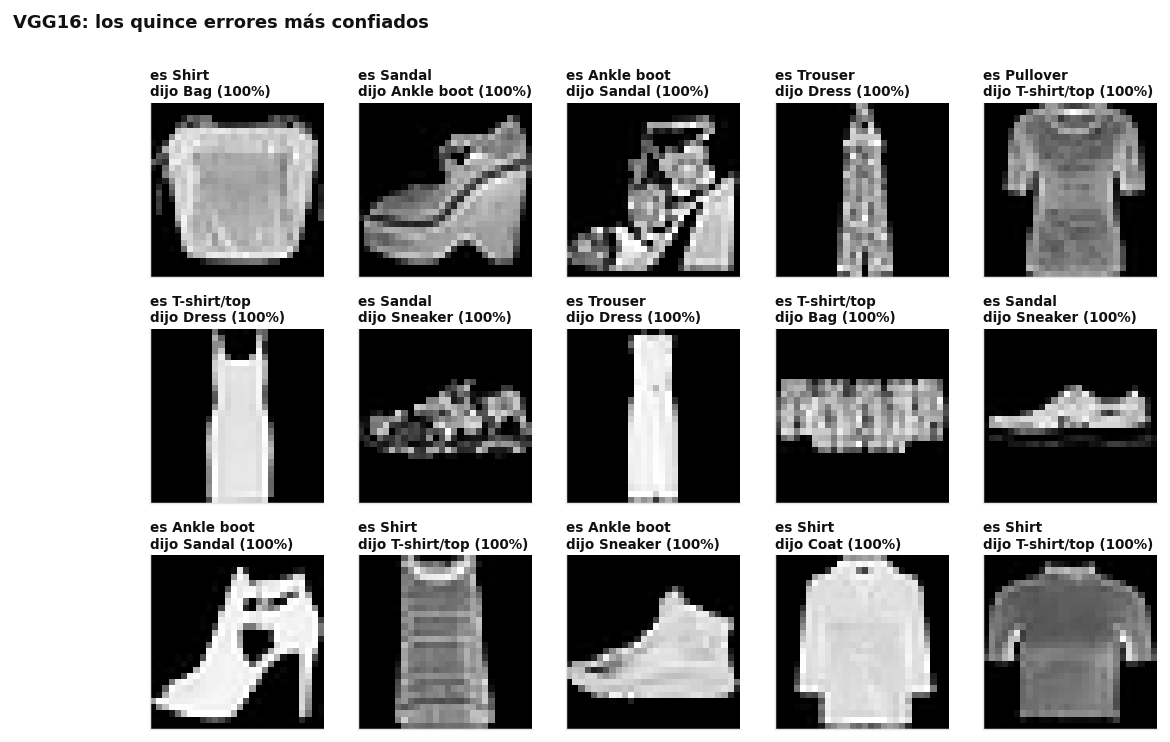

In [9]:
if pred is not None and met is not None:
    mejor = met.sort_values("F1_macro", ascending=False).iloc[0].Modelo
    fallos = np.where(preds[mejor] != y_test)[0]
    fallos = fallos[np.argsort(probs[mejor][fallos, preds[mejor][fallos]])[::-1][:15]]

    fig, ejes = plt.subplots(3, 5, figsize=(10, 6.4))
    for i, a in zip(fallos, ejes.flat):
        a.imshow(x_test[i], cmap="gray", interpolation="nearest")
        confianza = probs[mejor][i, preds[mejor][i]]
        a.set_title(f"es {CLASES[y_test[i]]}\ndijo {CLASES[preds[mejor][i]]} ({confianza:.0%})",
                    fontsize=7.5, pad=4)
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
        for lado in a.spines.values():
            lado.set_color(MALLA)
    fig.suptitle(f"{NOMBRE[mejor]}: los quince errores más confiados",
                 x=ejes[0, 0].get_position().x0, ha="left", fontsize=10, fontweight="semibold")
    fig.savefig(RUTA_RES / "fig_errores.png")
    plt.show()


## 8. Tablas para el informe

Cada tabla sale en `.csv`, en `.tex` (para pegar en LaTeX) y en `.md` (para Word). Los nombres
empiezan por `tabla_`.

In [10]:
def exportar(df, nombre, titulo, indice=False):
    """Deja la misma tabla en csv, LaTeX y Markdown."""
    df.to_csv(RUTA_RES / f"tabla_{nombre}.csv", index=indice)
    with open(RUTA_RES / f"tabla_{nombre}.tex", "w", encoding="utf-8") as f:
        f.write(df.to_latex(index=indice, escape=True, caption=titulo,
                            label=f"tab:{nombre}", float_format="%.4f"))
    try:
        texto = f"**{titulo}**\n\n" + df.to_markdown(index=indice, floatfmt=".4f")
    except ImportError:
        print("  falta la librería tabulate, no se genera el .md de", nombre)
    else:
        (RUTA_RES / f"tabla_{nombre}.md").write_text(texto, encoding="utf-8")
    print("tabla_" + nombre, "->", len(df), "filas")
    display(df)


if met is not None and tiempos is not None and boot is not None:
    comparativa = (met.merge(tiempos.groupby("family", as_index=False).seconds.sum(),
                             left_on="Modelo", right_on="family").drop(columns="family")
                      .merge(boot[["Modelo", "IC95_inf", "IC95_sup"]], on="Modelo"))
    comparativa["Modelo"] = comparativa.Modelo.map(NOMBRE)
    comparativa["IC 95%"] = comparativa.apply(
        lambda r: f"[{r.IC95_inf:.4f}, {r.IC95_sup:.4f}]", axis=1)
    comparativa = comparativa[["Modelo", "Accuracy", "IC 95%", "F1_macro", "Precision_macro",
                               "Recall_macro", "LogLoss", "Parametros", "Entrenables", "seconds"]]
    comparativa.columns = ["Modelo", "Accuracy", "IC 95%", "F1 macro", "Precisión macro",
                           "Recall macro", "Log-loss", "Parámetros", "Entrenables", "Tiempo (s)"]
    exportar(comparativa, "comparativa",
             "Comparación de las tres aproximaciones sobre el conjunto de test (10 000 imágenes)")


tabla_comparativa -> 3 filas


,Modelo,Accuracy,IC 95%,F1 macro,Precisión macro,Recall macro,Log-loss,Parámetros,Entrenables,Tiempo (s)
0,VGG16,0.9319,"[0.9269, 0.9367]",0.931924,0.932685,0.9319,0.192505,14719818,7084554,2687.005973
1,MobileNetV2,0.9243,"[0.9190, 0.9295]",0.924399,0.924793,0.9243,0.230052,2270794,1207690,339.945875
2,CNN desde cero,0.8904,"[0.8846, 0.8963]",0.890365,0.890618,0.8904,0.309533,28714,28522,78.706619


In [11]:
if exp is not None:
    busqueda = exp.copy()
    busqueda["Configuración"] = busqueda.config.map(lambda s: etiqueta_config(json.loads(s)))
    busqueda["Modelo"] = busqueda.family.map(NOMBRE)
    busqueda = (busqueda[["Modelo", "Configuración", "best_epoch", "val_accuracy", "val_loss",
                          "gap", "seconds"]]
                .sort_values(["Modelo", "val_loss"]))
    busqueda.columns = ["Modelo", "Configuración", "Mejor época", "Accuracy val.", "Pérdida val.",
                        "Brecha", "Tiempo (s)"]
    exportar(busqueda, "busqueda",
             "Búsqueda de hiperparámetros: una fila por corrida, ordenadas por pérdida de validación")


tabla_busqueda -> 10 filas


,Modelo,Configuración,Mejor época,Accuracy val.,Pérdida val.,Brecha,Tiempo (s)
0,CNN desde cero,32-64 · drop 0 · sin aug · lr 0.001,11,0.876500,0.350840,0.013667,39.865406
2,CNN desde cero,64-128 · drop 0.3 · aug · lr 0.001,10,0.825333,0.491559,-0.015130,90.615133
1,CNN desde cero,32-64 · drop 0.3 · aug · lr 0.001,12,0.821167,0.494393,-0.012037,71.593804
3,CNN desde cero,32-64 · drop 0.3 · aug · lr 0.0001,12,0.725333,0.750603,-0.016074,60.145699
7,MobileNetV2,drop 0.2 · sin aug · lr 0.001,10,0.901333,0.266893,-0.002741,149.643471
8,MobileNetV2,drop 0.3 · aug · lr 0.001,10,0.861667,0.373307,-0.013000,238.343783
9,MobileNetV2,drop 0.3 · aug · lr 0.0001,12,0.841833,0.418430,-0.010500,236.159846
4,VGG16,drop 0.2 · sin aug · lr 0.001,10,0.883000,0.323841,-0.012130,888.956065
5,VGG16,drop 0.4 · aug · lr 0.001,12,0.843667,0.436771,-0.030611,621.249355
6,VGG16,drop 0.4 · aug · lr 0.0001,12,0.829833,0.518744,-0.050944,617.129193


In [12]:
if pred is not None:
    por_clase = f1.copy()
    por_clase.columns = [NOMBRE[c] for c in por_clase.columns]
    por_clase.index.name = "Clase"
    exportar(por_clase.reset_index(), "f1_por_clase", "F1 por clase de las tres aproximaciones")


tabla_f1_por_clase -> 10 filas


,Clase,CNN desde cero,VGG16,MobileNetV2
0,Shirt,0.706660,0.793970,0.775124
1,T-shirt/top,0.834731,0.886429,0.878773
2,Coat,0.820991,0.906640,0.891519
3,Pullover,0.841463,0.906282,0.892072
4,Dress,0.876238,0.927026,0.918511
5,Sneaker,0.945759,0.965887,0.963145
6,Ankle boot,0.958711,0.964451,0.963340
7,Sandal,0.965898,0.987039,0.984523
8,Bag,0.974026,0.990050,0.988060
9,Trouser,0.979177,0.991462,0.988922


In [13]:
print("figuras y tablas en results/punto2/:\n")
for p in sorted(RUTA_RES.iterdir()):
    if p.suffix in {".png", ".tex", ".md"} or p.name.startswith("tabla_"):
        print(f"  {p.name:<32} {p.stat().st_size / 1024:7.1f} KB")


figuras y tablas en results/punto2/:

  busqueda.png                        49.4 KB
  confusion.png                      217.4 KB
  curvas.png                         320.6 KB
  ejemplos_clases.png                 48.0 KB
  errores.png                         90.6 KB
  fig_busqueda.png                   280.8 KB
  fig_clases.png                      69.3 KB
  fig_comparacion.png                145.2 KB
  fig_confusion.png                  227.2 KB
  fig_curvas.png                     259.6 KB
  fig_errores.png                    157.7 KB
  fig_f1_clase.png                   101.2 KB
  tabla_busqueda.csv                   1.3 KB
  tabla_busqueda.md                    1.7 KB
  tabla_busqueda.tex                   1.2 KB
  tabla_comparativa.csv                0.5 KB
  tabla_comparativa.md                 0.9 KB
  tabla_comparativa.tex                0.7 KB
  tabla_f1_por_clase.csv               0.7 KB
  tabla_f1_por_clase.md                0.8 KB
  tabla_f1_por_clase.tex               0.6